<a target="_blank" href="https://colab.research.google.com/github/seap-udea/fargopy/blob/main/examples/fargopy-tutorial-vector_fields.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<p align="left"><img src="https://github.com/seap-udea/fargopy/raw/refactor/docs/fargopy_logo.webp" width="300" /></p>

# Tutorial: vector fields

In [1]:
try:
    from google.colab import drive
    %pip install -Uq git+https://github.com/seap-udea/fargopy
except ImportError:
    print("Not running in Colab, skipping installation")
    %load_ext autoreload
    %autoreload 2
!mkdir -p ./gallery/


Not running in Colab, skipping installation


### What's in this notebook

In this notebook we illustrate **how to manipulate vector fields** in `FARGOpy`.  

Our goal is to create an animation like this:

<p align="center"><img src="../gallery/p3disoj-slow.gif" alt="Animation""/></p>

### Before starting

For this tutorial you will need the following external modules and tools:

In [2]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from celluloid import Camera
from tqdm import tqdm
from IPython.display import HTML

Your configuration file version '1.0.8' it is different than the installed version of FARGOpy '1.0.9'
Running FARGOpy version 1.0.9


### Let's `FARGOpy`

First we need the data. Let's download a precomputed simulation. Check the list:

In [3]:
fp.Simulation.list_precomputed()

fargo:
	Description: Protoplanetary disk with a Jovian planet [2D]
	Size: 55 MB
p3diso:
	Description: Protoplanetary disk with a Super earth planet [3D]
	Size: 220 MB
p3disoj:
	Description: Protoplanetary disk with a Jovian planet [3D]
	Size: 84 MB
fargo_multifluid:
	Description: Protoplanetary disk with several fluids (dust) and a Jovian planet in 2D
	Size: 100 MB
binary:
	Description: Disk around a binary with the properties of Kepler-38 in 2D
	Size: 140 MB
pds70iso:
	Description: PDS-70c - isothermal protoplanetary disk and circumplanetary disk in [3D]
	Size: 2940 MB


Download, for instance, the 2D simulation of a disk with a Jovian planet:

In [4]:
fp.Simulation.download_precomputed('p3disoj')

Precomputed output directory '/tmp/p3disoj' already exist


'/tmp/p3disoj'

Once download it, we need to connect a `Simulation` with the directory with the simulation results:

In [5]:
sim = fp.Simulation(output_dir='/tmp/p3disoj')

Your simulation is now connected with '/Users/jzuluaga/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat:
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


Let's load the velocity as a vector field from the latest snapshot:

In [31]:
fields = sim.load_field(
    fields=['gasv','gasdens'],
    snapshot=10,
    coords='cartesian',
    slice="phi=0"
)

Let's generate the cartesian components of the vector field:

In [32]:
fields.gasv_mesh[0].shape

(3, 32, 64)

In [33]:
x = fields.var1_mesh[0]
z = fields.var3_mesh[0]
gasvx, gasvy, gasvz = fields.gasv_mesh[0][0], fields.gasv_mesh[0][1], fields.gasv_mesh[0][2]

And plot a heat map of the $v_z$ component in that plane:

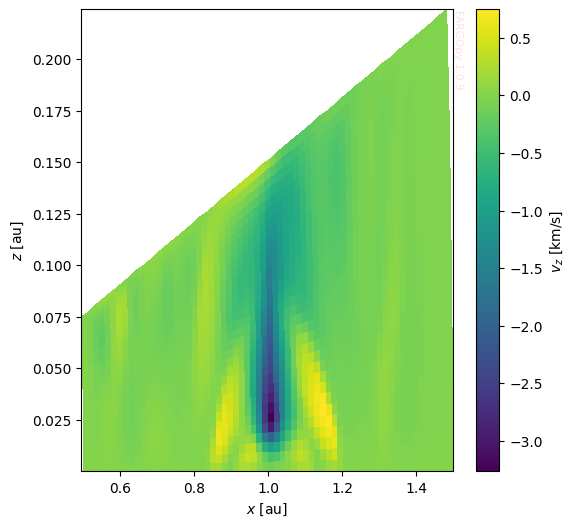

In [34]:
fig,axs = plt.subplots(1,1,figsize=(6,6))

cmap = 'viridis'
ax = axs

# Heat map of the vertical component of velocity
c = ax.pcolormesh(x*sim.UL/fp.AU,z*sim.UL/fp.AU,gasvz*sim.UV/(1e5),cmap=cmap)
cbar = fig.colorbar(c)
cbar.set_label('$v_z$ [km/s]')

ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$z$ [au]')
fp.Plot.fargopy_mark(ax)
plt.savefig('gallery/fargopy-tutorial-vector_fields_0.png') # Save figure


Now, we want to create a vector field of the velocity, superimposed to the gas density field.  We need to load the `gasdens` field and slice it:

In [35]:
gasd = fields.gasdens_mesh[0]

Now use `quiver` to plot the components of the velocity:

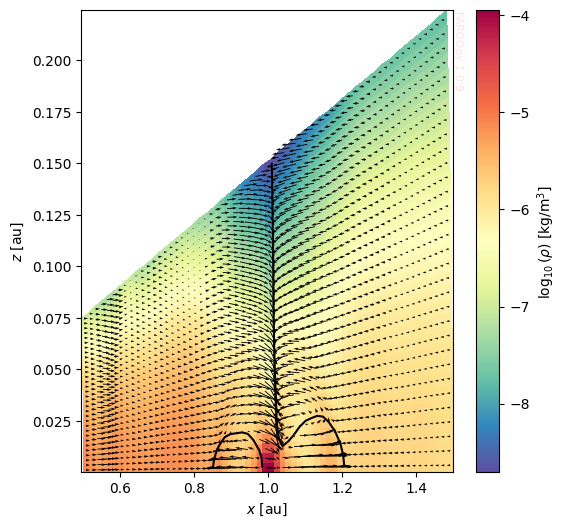

In [36]:
fig,axs = plt.subplots(1,1,figsize=(6,6))

cmap = 'Spectral_r'

# Colormap of the logaritmic density
pc = axs.pcolormesh(x*sim.UL/fp.AU,z*sim.UL/fp.AU,np.log10(gasd*sim.URHO*1e3),cmap=cmap)
cbar = fig.colorbar(pc)
cbar.set_label(r'$\log_{10}(\rho)$ [kg/m$^3$]')

# Line of vx = 0 velocity (vertical motion of the gas)
c = axs.contour(x*sim.UL/fp.AU,z*sim.UL/fp.AU,gasvx,levels=0,colors='k')

# Show the velocity field
freq = 1
axs.quiver(x[::freq,::freq]*sim.UL/fp.AU,
           z[::freq,::freq]*sim.UL/fp.AU,
           gasvx[::freq,::freq],
           gasvz[::freq,::freq],
           scale=2)
axs.set_xlabel('$x$ [au]')
axs.set_ylabel('$z$ [au]')
fp.Plot.fargopy_mark(axs)
plt.savefig('gallery/fargopy-tutorial-vector_fields_1.png') # Save figure


### Animating the velocity field

Now we can attempt to animate the velocity field evolution. For that purpose we use the methods found in the [animation tutorial](https://colab.research.google.com/github/seap-udea/fargopy/blob/main/examples/fargopy-tutorial-animations.ipynb). For that purpose we need to load the fields at all snapshots:

In [40]:
fields = sim.load_field(
    fields=['gasv','gasdens'],
    snapshot=[1,sim.nsnaps-1],
    coords='cartesian',
    slice="phi=0"
)

Now make the animation:

In [41]:
plt.ioff()
fig,axs = plt.subplots(1,1,figsize=(6,6))
cmap = 'Spectral_r'
camera = Camera(fig)

axs.set_xlabel('$x$ [au]')
axs.set_ylabel('$z$ [au]')
fp.Plot.fargopy_mark(axs)

for snapshot in tqdm(range(sim.nsnaps-1)):

    x = fields.var1_mesh[snapshot]
    z = fields.var3_mesh[snapshot]
    gasvx, gasvy, gasvz = fields.gasv_mesh[snapshot][0], fields.gasv_mesh[snapshot][1], fields.gasv_mesh[snapshot][2]
    gasd = fields.gasdens_mesh[snapshot]

    # Colormap of the logaritmic density
    pc = axs.pcolormesh(x*sim.UL/fp.AU,z*sim.UL/fp.AU,np.log10(gasd*sim.URHO*1e3),cmap=cmap)
    
    # Show the velocity field
    freq = 1
    axs.quiver(x[::freq,::freq]*sim.UL/fp.AU,
            z[::freq,::freq]*sim.UL/fp.AU,
            gasvx[::freq,::freq],
            gasvz[::freq,::freq],
            scale=2)

    camera.snap()

plt.ion()
animation = camera.animate(interval=100,blit=True)

print(f"Generating animation (it may takes a while, go for a coffee)...")
animation.save('gallery/p3disoj.gif',fps=5)
HTML(animation.to_jshtml())


100%|██████████| 10/10 [00:00<00:00, 206.09it/s]


Generating animation (it may takes a while, go for a coffee)...


Visualize it (if you insist on to wait for a while):

---
*Powered by fargopy*. For more examples see [fargopy GitHub repo](https://github.com/seap-udea/fargopy/tree/main/examples). 

Jorge I. Zuluaga, Alejandro Murillo-González and Matías Montesinos © 2023-present
